# Spike-Phase Coupling: How Neural Firing Relates to LFP Oscillations

When recording intracranially (e.g. with depth electrodes in epilepsy patients), we can observe two signals simultaneously:

1. **Local Field Potentials (LFP)** — the summed electrical activity of a neural population, similar to what EEG measures but recorded directly inside the brain. Like EEG, the LFP shows oscillations at different frequencies (theta, alpha, gamma, etc.).
2. **Single-neuron spikes** — the action potentials of individual neurons, detected as sharp voltage deflections.

A natural question is: **do neurons tend to fire at specific phases of LFP oscillations?** This phenomenon is called *spike-phase coupling* (or spike-field coupling), and it suggests that oscillations coordinate neural activity.

In this demo, we analyze data from a single neuron recorded in the human medial temporal lobe during a working memory task. The LFP phase has already been extracted using Morlet wavelet decomposition across 150 log-spaced frequencies (2–150 Hz).

## 1. Loading the Data

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

We have two pre-processed files for one recording session:

- **Spike raster**: a binary matrix (trials x time) where 1 indicates that the neuron fired at that millisecond
- **LFP phase**: the instantaneous phase of the LFP at each timepoint, computed via Morlet wavelets for 150 log-spaced frequencies from 2 to 150 Hz. Shape is (trials x frequencies x time).

Both are extracted from the **delay period** of a working memory task (2000 ms where the participant holds items in memory).

In [99]:
data_dir = Path("data")
raster_file = np.load(data_dir / "raster.npz")
phase_file = np.load(data_dir / "phase.npz")

# Extract delay-period data
spikes = raster_file["spike_with_ps_delay"]  # (trials, time) - binary spike raster
phases = phase_file["phase_with_ps_delay"]    # (trials, freqs, time) - LFP phase in radians

# The frequencies used for the wavelet decomposition
freqs = np.logspace(np.log10(2), np.log10(150), 150)

n_trials, n_timepoints = spikes.shape
n_freqs = phases.shape[1]

print(f"Spike raster: {n_trials} trials x {n_timepoints} ms")
print(f"LFP phase:    {n_trials} trials x {n_freqs} frequencies x {n_timepoints} ms")
print(f"Total spikes: {int(spikes.sum())}")
print(f"Frequency range: {freqs[0]:.1f} - {freqs[-1]:.1f} Hz")

Spike raster: 112 trials x 2000 ms
LFP phase:    112 trials x 150 frequencies x 2000 ms
Total spikes: 1222
Frequency range: 2.0 - 150.0 Hz


## 2. Visualizing the Spike Raster

A spike raster plot shows when a neuron fires across repeated trials. Each row is a trial, each dot marks a spike. This gives us a sense of the neuron's firing pattern.

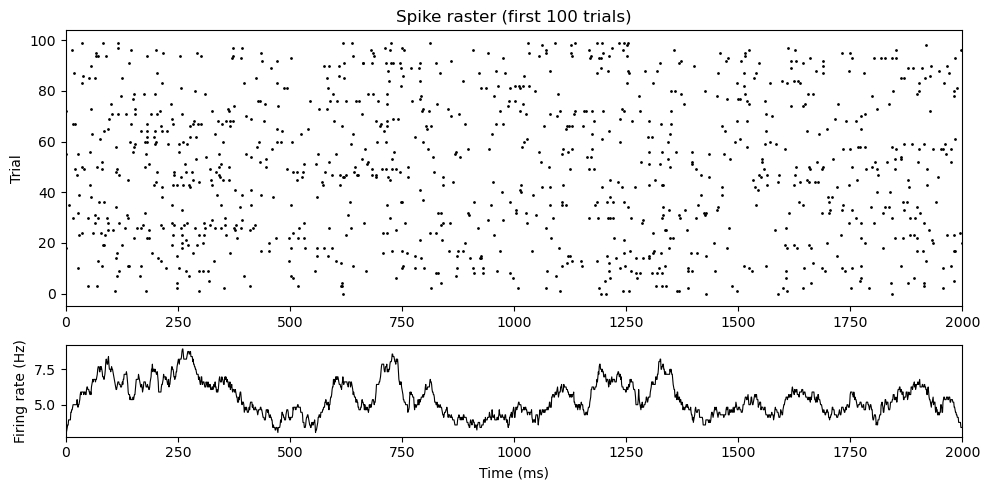

In [100]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), gridspec_kw={"height_ratios": [3, 1]})

n_show = 100
for trial in range(n_show):
    spike_times = np.where(spikes[trial] > 0)[0]
    axes[0].scatter(spike_times, np.full_like(spike_times, trial), s=1, c="black")

axes[0].set_ylabel("Trial")
axes[0].set_xlim(0, n_timepoints)
axes[0].set_title(f"Spike raster (first {n_show} trials)")

window_ms = 50
kernel = np.ones(window_ms) / (window_ms / 1000)  # normalize to spikes/s
firing_rate = np.convolve(spikes.mean(axis=0), kernel, mode="same")
axes[1].plot(firing_rate, color="black", linewidth=0.8)
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Firing rate (Hz)")
axes[1].set_xlim(0, n_timepoints)

plt.tight_layout()
plt.show()

## 3. Visualizing LFP Phase and Spike Times

To build intuition for spike-phase coupling, let's look at the LFP phase in the **theta band (~4 Hz)** for a few trials and overlay the spike times. If spikes are phase-locked, we would expect them to cluster at similar phase values.

Using frequency: 4.01 Hz


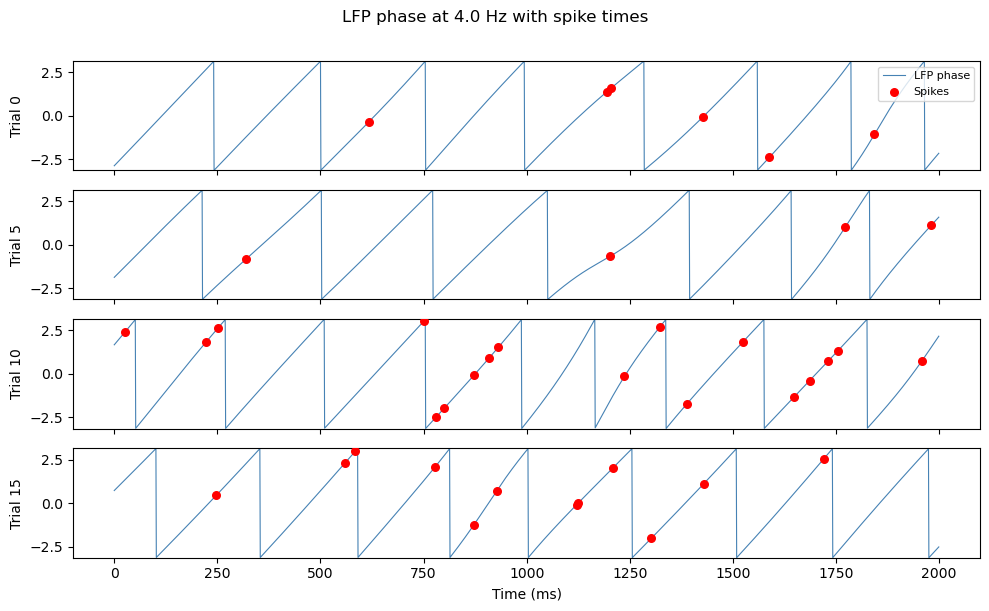

In [101]:
# Pick a theta frequency (~4 Hz)
theta_freq_idx = np.argmin(np.abs(freqs - 4.0))
print(f"Using frequency: {freqs[theta_freq_idx]:.2f} Hz")

fig, axes = plt.subplots(4, 1, figsize=(10, 6), sharex=True)

for i, trial in enumerate([0, 5, 10, 15]):
    ax = axes[i]
    phase_trace = phases[trial, theta_freq_idx, :]
    ax.plot(phase_trace, color="steelblue", linewidth=0.8, label="LFP phase")

    spike_times = np.where(spikes[trial] > 0)[0]
    if len(spike_times) > 0:
        ax.scatter(
            spike_times, phase_trace[spike_times],
            color="red", s=30, zorder=5, label="Spikes"
        )

    ax.set_ylabel(f"Trial {trial}")
    ax.set_ylim(-np.pi, np.pi)
    if i == 0:
        ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time (ms)")
fig.suptitle(f"LFP phase at {freqs[theta_freq_idx]:.1f} Hz with spike times", y=1.01)
plt.tight_layout()
plt.show()

## 4. Extracting Phases at Spike Times

The core idea of spike-phase coupling analysis is simple: for every spike, we look up the LFP phase at that moment, across all frequencies. If a neuron tends to fire at a consistent phase (e.g. always near the trough of theta), the phase values will cluster rather than being uniformly distributed around the circle.

In [102]:
# Find all (trial, time) locations where a spike occurred
spike_trials, spike_times = np.where(spikes > 0)

# For each spike, get the LFP phase at all 150 frequencies
# phases has shape (trials, freqs, time) - we index with the spike locations
phases_at_spikes = phases[spike_trials, :, spike_times]  # shape: (n_spikes, n_freqs)

print(f"Number of spikes: {len(spike_trials)}")
print(f"Phases at spikes: {phases_at_spikes.shape}  (spikes x frequencies)")

Number of spikes: 1222
Phases at spikes: (1222, 150)  (spikes x frequencies)


## 5. Phase Distribution at Spike Times

Let's visualize the distribution of phases at which this neuron fires, focusing on the **theta band (2.5-5 Hz)** and the **high gamma band (60-150 Hz)**. A polar histogram shows the circular distribution of phases. If spikes are phase-locked, we'll see a non-uniform distribution with a clear peak.

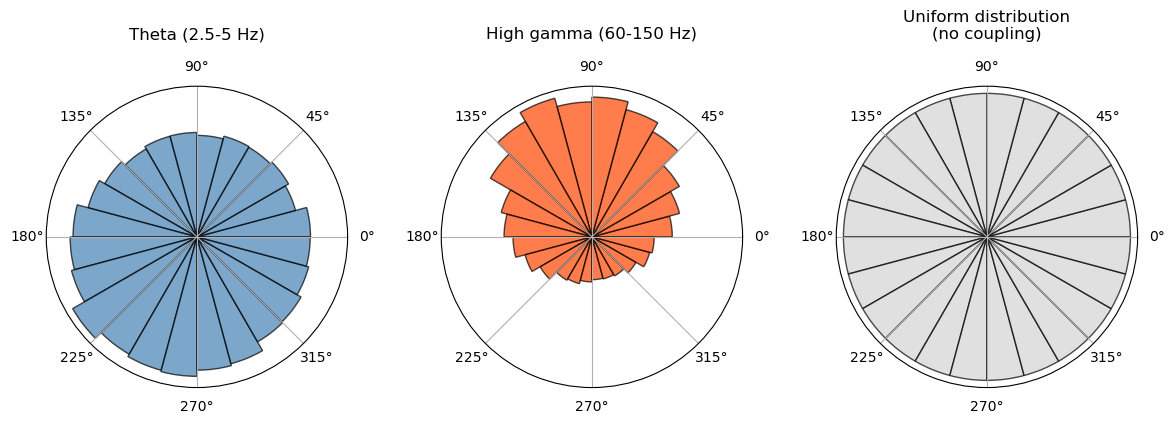

In [103]:
# Select frequency bands
theta_mask = (freqs > 2.5) & (freqs < 5)
gamma_mask = (freqs > 60) & (freqs < 150)

theta_phases = phases_at_spikes[:, theta_mask].flatten()
gamma_phases = phases_at_spikes[:, gamma_mask].flatten()

fig, axes = plt.subplots(1, 3, figsize=(12, 4),
                         subplot_kw={"projection": "polar"})

n_bins = 24
bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Theta
theta_counts, _ = np.histogram(theta_phases, bins=bin_edges)
axes[0].bar(bin_centers, theta_counts, width=bin_width, color="steelblue",
            edgecolor="black", alpha=0.7)
axes[0].set_title("Theta (2.5-5 Hz)", pad=15)

# High gamma
gamma_counts, _ = np.histogram(gamma_phases, bins=bin_edges)
axes[1].bar(bin_centers, gamma_counts, width=bin_width, color="orangered",
            edgecolor="black", alpha=0.7)
axes[1].set_title("High gamma (60-150 Hz)", pad=15)

# Uniform reference
uniform_counts = np.full(n_bins, len(theta_phases) / n_bins)
axes[2].bar(bin_centers, uniform_counts, width=bin_width, color="lightgray",
            edgecolor="black", alpha=0.7)
axes[2].set_title("Uniform distribution\n(no coupling)", pad=15)

for ax in axes:
    ax.set_yticklabels([])
    ax.set_rticks([])

plt.tight_layout()
plt.show()

## 6. Quantifying Coupling Strength: Mean Vector Length

The **Mean Vector Length (MVL)** quantifies how strongly spikes are locked to a particular phase. Each spike phase is treated as a unit vector on the circle. If all spikes occur at the same phase, the vectors add up and MVL approaches 1. If spikes are uniformly distributed, they cancel out and MVL approaches 0.

$$\text{MVL} = \left| \frac{1}{N} \sum_{k=1}^{N} e^{i \phi_k} \right|$$

Because MVL is sensitive to sample size (fewer spikes lead to higher MVL by chance), we use a bootstrap approach: repeatedly subsample a fixed number of spikes, compute MVL for each subsample, and average.

In [104]:
def compute_mvl(spike_phases, n_repetitions=500, n_spikes_per_sample=20):
    """Compute bootstrapped Mean Vector Length for each frequency.

    Parameters
    ----------
    spike_phases : array of shape (n_spikes, n_freqs)
        Phase values at spike times for each frequency.
    n_repetitions : int
        Number of bootstrap iterations.
    n_spikes_per_sample : int
        Spikes to subsample per iteration.

    Returns
    -------
    mvl : array of shape (n_freqs,)
    """
    n_spikes, n_freqs = spike_phases.shape
    if n_spikes < n_spikes_per_sample:
        return np.full(n_freqs, np.nan)

    mvl_samples = np.zeros((n_repetitions, n_freqs))
    for i in range(n_repetitions):
        idx = np.random.choice(n_spikes, n_spikes_per_sample, replace=False)
        mvl_samples[i] = np.abs(np.mean(np.exp(1j * spike_phases[idx]), axis=0))

    return mvl_samples.mean(axis=0)

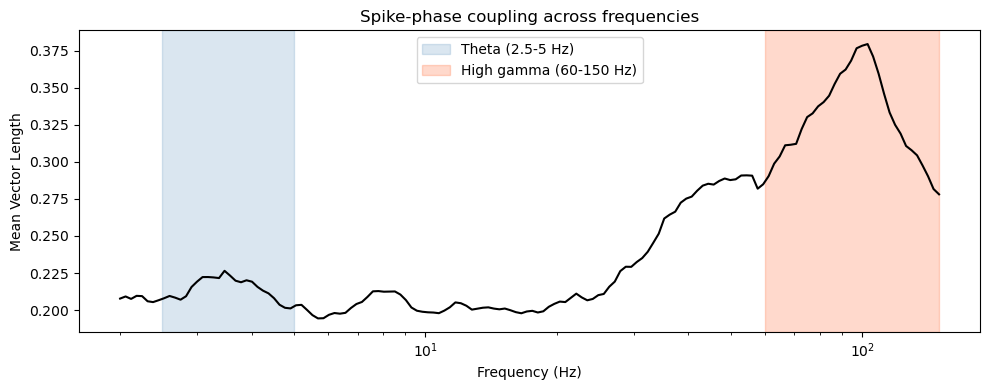

In [105]:
mvl = compute_mvl(phases_at_spikes)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, mvl, color="black", linewidth=1.5)

ax.axvspan(2.5, 5, alpha=0.2, color="steelblue", label="Theta (2.5-5 Hz)")
ax.axvspan(60, 150, alpha=0.2, color="orangered", label="High gamma (60-150 Hz)")

ax.set_xscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Mean Vector Length")
ax.set_title("Spike-phase coupling across frequencies")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Comparing Conditions: Preferred vs Non-Preferred Stimulus

This neuron was recorded during a working memory task where the participant memorized a sequence of images. Some images are the neuron's **preferred stimulus** (PS) — the image that makes it fire most — while others are **non-preferred (NPS)**.

We can ask: is the spike-phase coupling different when the preferred stimulus is held in memory vs when it is absent? If so, this would suggest that oscillatory phase plays a functional role in memory maintenance, not just a general coordination mechanism.

Preferred stimulus present:  1222 spikes
Preferred stimulus absent:   1052 spikes


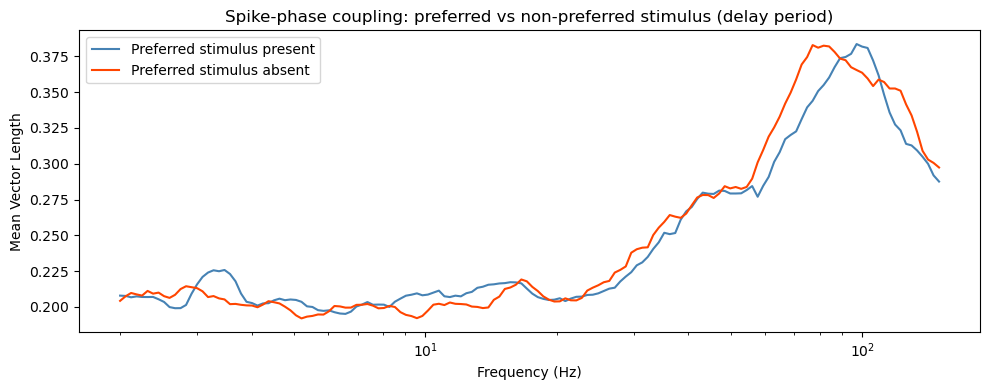

In [106]:
# Load both conditions for the delay period
spikes_ps = raster_file["spike_with_ps_delay"]
spikes_nps = raster_file["spike_without_ps_delay"]
phases_ps = phase_file["phase_with_ps_delay"]
phases_nps = phase_file["phase_without_ps_delay"]

# Extract phases at spike times for each condition
ps_trials, ps_times = np.where(spikes_ps > 0)
phases_at_spikes_ps = phases_ps[ps_trials, :, ps_times]

nps_trials, nps_times = np.where(spikes_nps > 0)
phases_at_spikes_nps = phases_nps[nps_trials, :, nps_times]

print(f"Preferred stimulus present:  {len(ps_trials)} spikes")
print(f"Preferred stimulus absent:   {len(nps_trials)} spikes")

# Compute MVL for each condition
mvl_ps = compute_mvl(phases_at_spikes_ps)
mvl_nps = compute_mvl(phases_at_spikes_nps)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, mvl_ps, color="steelblue", linewidth=1.5, label="Preferred stimulus present")
ax.plot(freqs, mvl_nps, color="orangered", linewidth=1.5, label="Preferred stimulus absent")

ax.set_xscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Mean Vector Length")
ax.set_title("Spike-phase coupling: preferred vs non-preferred stimulus (delay period)")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

In this demo we saw that:

1. **Intracranial recordings** give us access to both the LFP (which is the local equivalent of what EEG measures) and individual neuron spikes.
2. By extracting the **LFP phase at each spike time**, we can test whether a neuron fires preferentially at certain phases of ongoing oscillations.
3. The **Mean Vector Length** quantifies the strength of this phase-locking for any frequency band.
4. This neuron shows coupling primarily in the **high gamma range**, consistent with the idea that high-frequency oscillations reflect local neural firing.
5. Comparing conditions reveals that spike-phase coupling can differ depending on the **cognitive demands** of the task — here, whether the neuron's preferred stimulus is held in working memory.

This type of analysis bridges the gap between the macroscopic signals we measure with EEG/MEG and the single-neuron activity that ultimately drives behavior.